In [1]:
import tensorflow as tf
import numpy as np

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

# GENERADOR DE DATOS DE SATÉLITE OPTIMIZADO
class GeneradorParchesTFG(Sequence):
    def __init__(self, carpeta_parches, lista_archivos, batch_size=64, shuffle=True):
        self.carpeta = carpeta_parches
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.archivos_X = lista_archivos
        self.num_clases = 19
        self.indices = np.arange(len(self.archivos_X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.archivos_X) / self.batch_size))

    def __getitem__(self, index):
        indices_batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        
        batch_X = []
        batch_Y_porcentajes = []
        
        for idx in indices_batch:
            nom_X = self.archivos_X[idx]
            nom_Y = nom_X.replace('_X.npy', '_Y.npy')
            
            parche_X = np.load(os.path.join(self.carpeta, nom_X)).astype(np.float32)
            parche_Y = np.load(os.path.join(self.carpeta, nom_Y))
            
            if parche_X.shape[0] == 4:
                parche_X = np.transpose(parche_X, (1, 2, 0))
            
            parche_X = parche_X[:48, :48, :]
            parche_Y = parche_Y[:48, :48]
            
            for c in range(parche_X.shape[-1]):
                min_val = np.min(parche_X[:,:,c])
                max_val = np.max(parche_X[:,:,c])
                if max_val > min_val:
                    parche_X[:,:,c] = (parche_X[:,:,c] - min_val) / (max_val - min_val)
                else:
                    parche_X[:,:,c] = 0.0
            
            frecuencias = np.zeros(self.num_clases, dtype=np.float32)
            valores, counts = np.unique(parche_Y, return_counts=True)
            total_pixeles = parche_Y.size
            
            for v, c in zip(valores, counts):
                if 0 <= v < self.num_clases:
                    frecuencias[v] = c / total_pixeles
            
            suma_frec = np.sum(frecuencias)
            if float(suma_frec) == 0.0:
                continue
                
            frecuencias = frecuencias / suma_frec
            
            batch_X.append(parche_X)
            batch_Y_porcentajes.append(frecuencias)
            
        if len(batch_X) == 0:
            return np.zeros((1, 48, 48, 4), dtype=np.float32), np.zeros((1, self.num_clases), dtype=np.float32)
            
        return np.array(batch_X), np.array(batch_Y_porcentajes)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# PREPARACIÓN ESTRATIFICADA DEL DATASET (80/20)
carpeta_dataset = r"D:\TFG\dataset_parches_50x50"
todos_los_X = sorted([f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')])

# Usamos los primeros 50k archivos disponibles
np.random.seed(4215) 
np.random.shuffle(todos_los_X)
archivos_prueba = todos_los_X[:100000]

print("Calculando categorías predominantes para la estratificación...")
categorias_predominantes = []
for nom_X in archivos_prueba:
    nom_Y = nom_X.replace('_X.npy', '_Y.npy')
    parche_Y = np.load(os.path.join(carpeta_dataset, nom_Y))
    valores, counts = np.unique(parche_Y, return_counts=True)
    clase_principal = valores[np.argmax(counts)]
    categorias_predominantes.append(clase_principal)

categorias_predominantes = np.array(categorias_predominantes)

# Reparto del 80% y 20% manteniendo proporciones idénticas de categorías
archivos_train, archivos_val = train_test_split(
    archivos_prueba, 
    test_size=0.2, 
    stratify=categorias_predominantes, 
    random_state=42
)

generador_train = GeneradorParchesTFG(carpeta_dataset, archivos_train, batch_size=64, shuffle=True)
generador_val = GeneradorParchesTFG(carpeta_dataset, archivos_val, batch_size=64, shuffle=False)

# 3. ARQUITECTURA RED CONVOLUCIONAL (48x48x4)
def build_model_distribucion(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # Capas de Data Augmentation para evitar que se memorice el desbalance
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    
    # Bloque Convolucional 1: Extracción de texturas básicas
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x) # Reduce a 24x24
    x = layers.Dropout(0.2)(x)
    
    # Bloque Convolucional 2: Combinaciones complejas de canales de satélite
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x) # Reduce a 12x12
    x = layers.Dropout(0.3)(x)
    
    # Reducción espacial global
    x = layers.GlobalAveragePooling2D()(x)
    
    # Bloque denso de regresión (MLP)
    x = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs=inputs, outputs=outputs)

# Instanciamos el modelo
model = build_model_distribucion((48, 48, 4), 19)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3, clipnorm=0.5),
    loss='categorical_crossentropy', 
    metrics=['mae', 'accuracy'] 
)

mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

history = model.fit(
    generador_train,
    validation_data=generador_val,
    epochs=50,
    callbacks=mis_callbacks
)

Calculando categorías predominantes para la estratificación...
Epoch 1/50
1250/1250 [==============================] - 1096s 874ms/step - loss: 1.5008 - mae: 0.0553 - accuracy: 0.5967 - val_loss: 1.4823 - val_mae: 0.0665 - val_accuracy: 0.5120
Epoch 2/50
1250/1250 [==============================] - 1258s 1s/step - loss: 1.1420 - mae: 0.0501 - accuracy: 0.6421 - val_loss: 1.3515 - val_mae: 0.0510 - val_accuracy: 0.5914
Epoch 3/50
1250/1250 [==============================] - 1844s 1s/step - loss: 1.0863 - mae: 0.0480 - accuracy: 0.6584 - val_loss: 1.2064 - val_mae: 0.0493 - val_accuracy: 0.6309
Epoch 4/50
1250/1250 [==============================] - 1546s 1s/step - loss: 1.0592 - mae: 0.0467 - accuracy: 0.6670 - val_loss: 1.1914 - val_mae: 0.0518 - val_accuracy: 0.6429
Epoch 5/50
1250/1250 [==============================] - 1838s 1s/step - loss: 1.0342 - mae: 0.0456 - accuracy: 0.6737 - val_loss: 1.1767 - val_mae: 0.0450 - val_accuracy: 0.6477
Epoch 6/50
1250/1250 [======================

KeyboardInterrupt: 

Epoch 1/50
125/125 [==============================] - 52s 391ms/step - loss: 6.3950 - mae: 0.0948 - accuracy: 0.1340 - val_loss: 6.4317 - val_mae: 0.0991 - val_accuracy: 0.0000e+00 - lr: 1.0000e-04
Epoch 2/50
125/125 [==============================] - 53s 426ms/step - loss: 5.2897 - mae: 0.0864 - accuracy: 0.2825 - val_loss: 6.0331 - val_mae: 0.0943 - val_accuracy: 0.1450 - lr: 1.0000e-04
Epoch 3/50
125/125 [==============================] - 51s 398ms/step - loss: 4.6453 - mae: 0.0804 - accuracy: 0.3700 - val_loss: 5.2879 - val_mae: 0.0882 - val_accuracy: 0.1450 - lr: 1.0000e-04
Epoch 4/50
125/125 [==============================] - 47s 376ms/step - loss: 4.2350 - mae: 0.0746 - accuracy: 0.4470 - val_loss: 4.5202 - val_mae: 0.0823 - val_accuracy: 0.1970 - lr: 1.0000e-04
Epoch 5/50
125/125 [==============================] - 47s 380ms/step - loss: 3.9766 - mae: 0.0693 - accuracy: 0.5027 - val_loss: 3.8350 - val_mae: 0.0709 - val_accuracy: 0.4170 - lr: 1.0000e-04
Epoch 6/50
125/125 [======

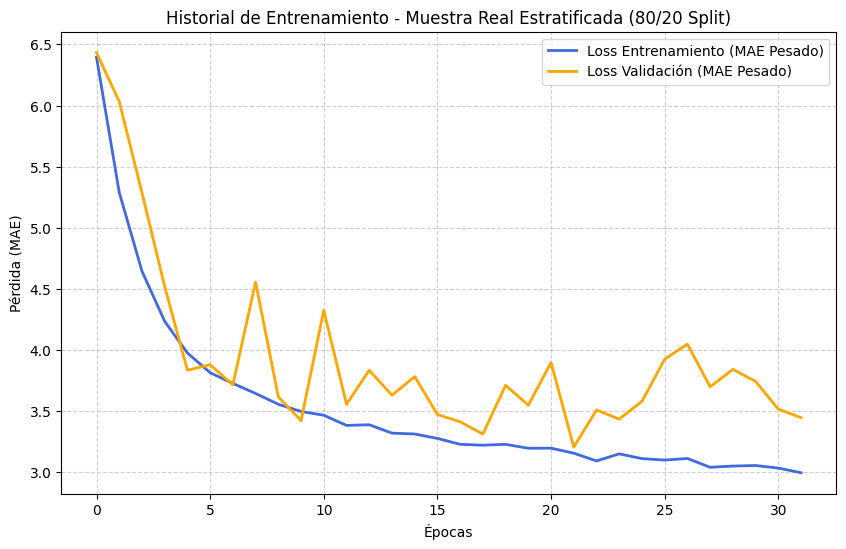

Evaluando el modelo en el conjunto de validación de forma estocástica...


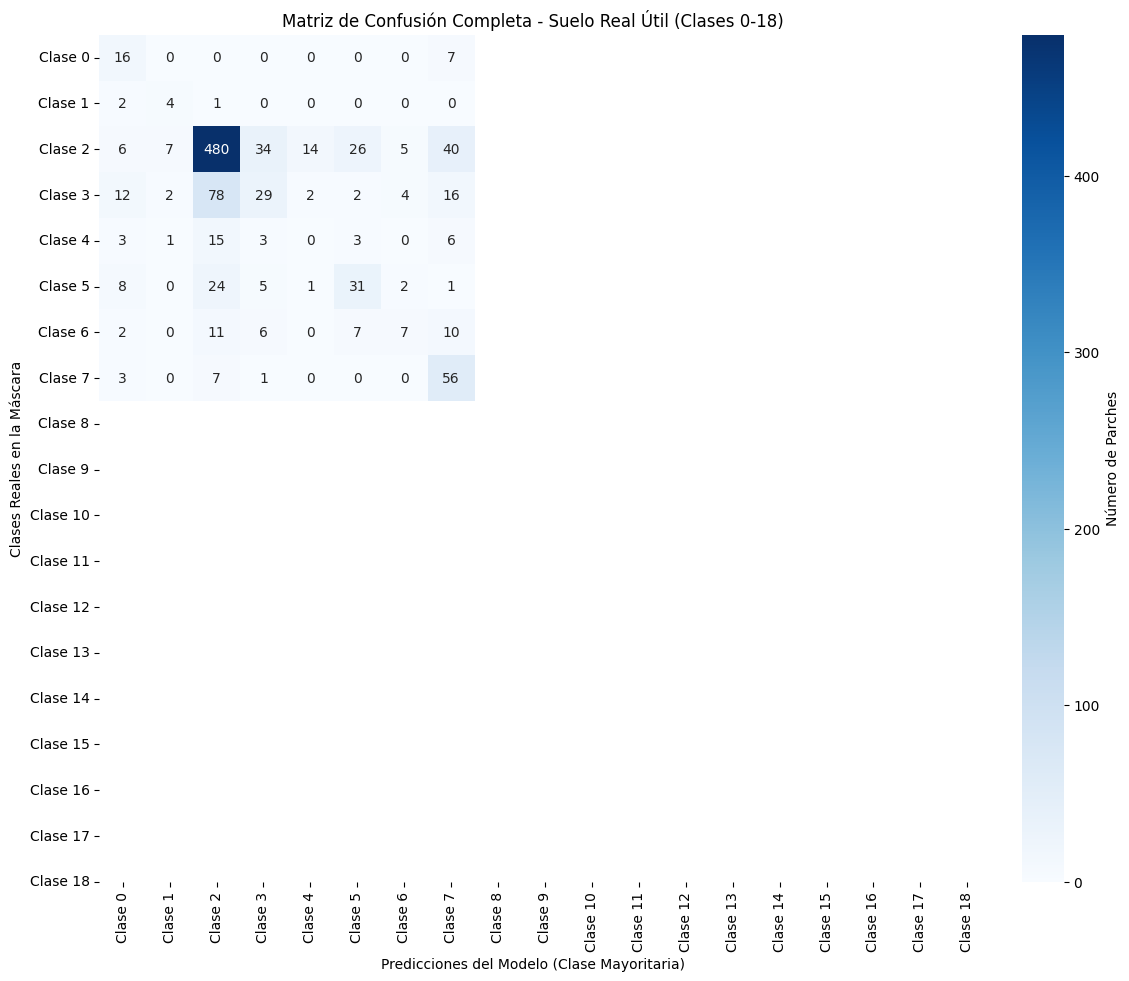


       MÉTRICAS FINALES (SITUACIÓN REAL VAL)
Accuracy General: 0.6230
Precision Macro:  0.3743
Recall Macro:     0.4601
F1-Score Macro:   0.3838


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score



# =====================================================================
# 1. GENERADOR DE DATOS DE SATÉLITE OPTIMIZADO (DISTRIBUCIÓN REAL)
# =====================================================================
class GeneradorParchesTFG(Sequence):
    def __init__(self, carpeta_parches, lista_archivos, batch_size=64, shuffle=True):
        self.carpeta = carpeta_parches
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.archivos_X = lista_archivos
        self.num_clases = 19 
        self.indices = np.arange(len(self.archivos_X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.archivos_X) / self.batch_size))

    def __getitem__(self, index):
        indices_batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_X = []
        batch_Y_porcentajes = []
        
        for idx in indices_batch:
            nom_X = self.archivos_X[idx]
            nom_Y = nom_X.replace('_X.npy', '_Y.npy')
            
            try:
                parche_X = np.load(os.path.join(self.carpeta, nom_X)).astype(np.float32)
                parche_Y = np.load(os.path.join(self.carpeta, nom_Y))
                
                if parche_X.shape[0] == 4:
                    parche_X = np.transpose(parche_X, (1, 2, 0))
                
                parche_X = parche_X[:48, :48, :]
                parche_Y = parche_Y[:48, :48]
                
                # --- LA MEJORA CLAVE: Normalización Min-Max Vectorizada (Sin bucles for) ---
                # Calculamos min y max de todo el parche a la vez en lugar de canal por canal
                min_val = parche_X.min(axis=(0, 1), keepdims=True)
                max_val = parche_X.max(axis=(0, 1), keepdims=True)
                rango = max_val - min_val
                parche_X = np.where(rango > 0, (parche_X - min_val) / rango, 0.0)
                
                frecuencias = np.zeros(self.num_clases, dtype=np.float32)
                valores, counts = np.unique(parche_Y, return_counts=True)
                
                for v, c in zip(valores, counts):
                    if 0 <= v < self.num_clases:
                        frecuencias[v] = c
                
                suma_frec = np.sum(frecuencias)
                if float(suma_frec) == 0.0:
                    continue 
                    
                frecuencias = frecuencias / suma_frec
                
                batch_X.append(parche_X)
                batch_Y_porcentajes.append(frecuencias)
            except Exception:
                continue
            
        if len(batch_X) == 0:
            return (np.zeros((1, 48, 48, 4), dtype=np.float32), np.zeros((1, self.num_clases), dtype=np.float32))
            
        return np.array(batch_X), np.array(batch_Y_porcentajes)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# =====================================================================
# 2. SELECCIÓN ALEATORIA ESTRATIFICADA (FILTRADO INMEDIATO DE CLASE 19)
# =====================================================================
carpeta_dataset = r"D:\TFG\dataset_parches_50x50"
ruta_guardado = r"modelocnnmlp.keras"

todos_los_X_total = [f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')]

np.random.seed(4215) 
np.random.shuffle(todos_los_X_total)

archivos_prueba = []
categorias_predominantes = []
cupo_deseado = 5000  

for nom_X in todos_los_X_total:
    if len(archivos_prueba) >= cupo_deseado:
        break
        
    nom_Y = nom_X.replace('_X.npy', '_Y.npy')
    try:
        parche_Y = np.load(os.path.join(carpeta_dataset, nom_Y))
        conteos = np.bincount(parche_Y.ravel(), minlength=20)
        clase_principal = np.argmax(conteos[:20])
        
        if clase_principal == 19:
            continue
            
        archivos_prueba.append(nom_X)
        categorias_predominantes.append(clase_principal)
    except Exception:
        continue

categorias_predominantes = np.array(categorias_predominantes)

archivos_train, archivos_val = train_test_split(
    archivos_prueba, 
    test_size=0.2, 
    stratify=categorias_predominantes, 
    random_state=42
)

generador_train = GeneradorParchesTFG(carpeta_dataset, archivos_train, batch_size=32, shuffle=True)
generador_val = GeneradorParchesTFG(carpeta_dataset, archivos_val, batch_size=32, shuffle=False)

# =====================================================================
# 3. ARQUITECTURA RED CONVOLUCIONAL (REGRESIÓN GLOBAL DE DISTRIBUCIONES)
# =====================================================================
def build_model_distribucion(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # Capas de Data Augmentation para robustez frente a variaciones de iluminación/ángulo
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    
    # Bloque Convolucional 1
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.Dropout(0.2)(x)
    
    # Bloque Convolucional 2
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.Dropout(0.3)(x)
    
    # Reducción espacial global
    x = layers.GlobalAveragePooling2D()(x)
    
    # Bloque denso fully-connected (MLP de salida continua)
    x = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs=inputs, outputs=outputs)

# Instanciamos el modelo con 19 neuronas de salida (índices 0 al 18)
model = build_model_distribucion((48, 48, 4), 19)


# =====================================================================
# 4. FUNCIÓN DE PÉRDIDA PESADA PERSONALIZADA PARA LA MESETA CENTRAL
# =====================================================================
# Pesos calculados exactamente basándose en el análisis matemático de tu dataset
PESOS_REALES_MESETA = tf.constant([
    4.5,  # Clase 0
    8.3,  # Clase 1 
    1.0,  # Clase 2 (Base)
    2.0,  # Clase 3
    4.2,  # Clase 4
    2.7,  # Clase 5
    3.3,  # Clase 6
    2.9,  # Clase 7
    0.0,  # Clase 8 
    0.0,  # Clase 9 
    0.0,  # Clase 10 
    10.0, # Clase 11 (Máximo castigo controlado)
    0.0,  # Clase 12 
    0.0,  # Clase 13 
    0.0,  # Clase 14 
    0.0,  # Clase 15 
    0.0,  # Clase 16 
    0.0,  # Clase 17 
    0.0   # Clase 18 
], dtype=tf.float32)

def categorical_crossentropy_pesada(y_true, y_pred):
    smooth = 1e-5
    y_pred = tf.clip_by_value(y_pred, smooth, 1.0 - smooth)
    
    # Pérdida de entropía cruzada continua píxel a píxel / porcentaje a porcentaje
    cce_por_parche = -y_true * tf.math.log(y_pred)
    
    # Aplicación de los multiplicadores de error según el uso de suelo real
    cce_pesada = cce_por_parche * PESOS_REALES_MESETA
    
    return tf.reduce_mean(tf.reduce_sum(cce_pesada, axis=-1))

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4, clipnorm=0.5),
    loss=categorical_crossentropy_pesada, 
    metrics=['mae', 'accuracy'] 
)

mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.7, patience=10, min_lr=1e-6, verbose=1)
]

# =====================================================================
# 5. EJECUCIÓN DEL ENTRENAMIENTO
# =====================================================================
history = model.fit(
    generador_train,
    validation_data=generador_val,
    epochs=50,
    callbacks=mis_callbacks
)

# =====================================================================
# 6. EVALUACIÓN DE MÉTRICAS GLOBALES Y GRÁFICAS (MUESTRA DE TEST 20K)
# =====================================================================
# 1. Gráfica de la curva de pérdida (MAE)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label="Loss Entrenamiento (MAE Pesado)", color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label="Loss Validación (MAE Pesado)", color='orange', linewidth=2)
plt.title("Historial de Entrenamiento - Muestra Real Estratificada (80/20 Split)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MAE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Extracción controlada de Ground Truth y Predicciones para métricas limpias
print("Evaluando el modelo en el conjunto de validación de forma estocástica...", flush=True)
y_true_list = []
y_pred_list = []

for i in range(len(generador_val)):
    bx, by = generador_val[i]
    preds = model.predict(bx, verbose=0)
    y_true_list.append(by)
    y_pred_list.append(preds)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

# Al trabajar con porcentajes continuos, extraemos el argmax para evaluar la matriz de confusión
y_true_classes = np.argmax(y_true, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# 3. Representación de la Matriz de Confusión limpia de Clase 19
clases_nombres = [f"Clase {i}" for i in range(19)]
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(14, 11))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=clases_nombres, 
    yticklabels=clases_nombres,
    cbar_kws={'label': 'Número de Parches'}
)
plt.xlabel('Predicciones del Modelo (Clase Mayoritaria)')
plt.ylabel('Clases Reales en la Máscara')
plt.title('Matriz de Confusión Completa - Suelo Real Útil (Clases 0-18)')
plt.show()

# 4. Cálculo final de las métricas de rendimiento globales
print("\n       MÉTRICAS FINALES (SITUACIÓN REAL VAL)")
print("="*40)
print(f"Accuracy General: {accuracy_score(y_true_classes, y_pred_classes):.4f}")
print(f"Precision Macro:  {precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"Recall Macro:     {recall_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"F1-Score Macro:   {f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print("="*40)

In [17]:
!pip install "matplotlib>=3.8.4,<3.10.0"

  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 7.8/7.8 MB 48.2 MB/s  0:00:00
Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp310-cp310-win_amd64.whl (1.6 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl (7.1 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ----- ---------------------------------- 1/7 [pillow]
   ---

In [26]:
!pip install "seaborn>=0.13.2,<0.14.0"

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pan

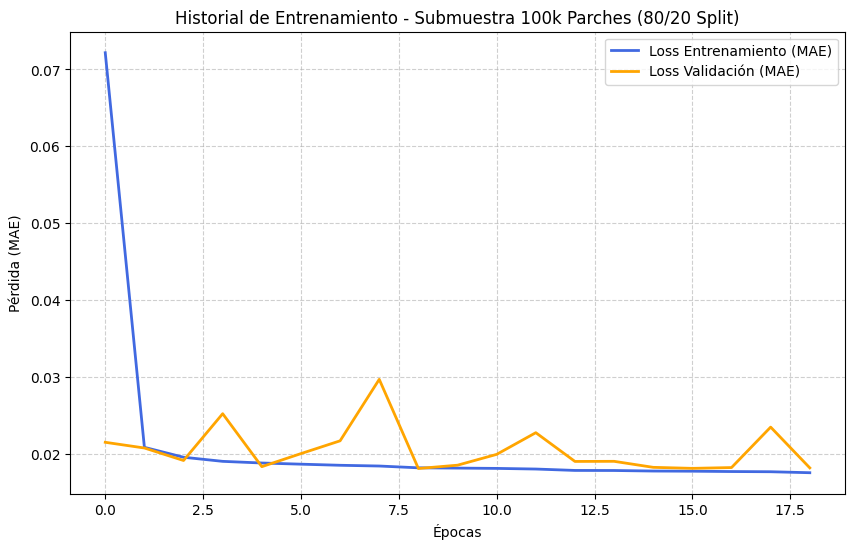

Evaluando el modelo en el conjunto de validación estocástico...


KeyboardInterrupt: 

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 5. GRÁFICAS DE RENDIMIENTO Y EVALUACIÓN (Validación 20k)
# ==========================================

# 1. Gráfica de la curva de pérdida (MAE)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label="Loss Entrenamiento (MAE)", color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label="Loss Validación (MAE)", color='orange', linewidth=2)
plt.title("Historial de Entrenamiento - Submuestra 100k Parches (80/20 Split)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MAE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Extracción controlada de Ground Truth y Predicciones usando el generador de validación
print("Evaluando el modelo en el conjunto de validación estocástico...")
y_true_list = []
y_pred_list = []

for i in range(len(generador_val)):
    bx, by = generador_val[i]
    preds = model.predict(bx, verbose=0)
    y_true_list.append(by)
    y_pred_list.append(preds)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

# Al trabajar con porcentajes, obtenemos la clase predominante (mayoritaria) para métricas estándar
y_true_classes = np.argmax(y_true, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# 3. Representación de la Matriz de Confusión
clases_nombres = [f"Clase {i}" for i in range(19)]
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(14, 11))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=clases_nombres, 
    yticklabels=clases_nombres,
    cbar_kws={'label': 'Número de Parches'}
)
plt.xlabel('Predicciones del Modelo (Clase Mayoritaria)')
plt.ylabel('Clases Reales en la Máscara')
plt.title('Matriz de Confusión - Conjunto de Validación (20k Parches)')
plt.show()

# 4. Cálculo e impresión de métricas de rendimiento globales
print("       MÉTRICAS FINALES (VALIDACIÓN)")
print("="*40)
print(f"Accuracy General: {accuracy_score(y_true_classes, y_pred_classes):.4f}")
print(f"Precision Macro:  {precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"Recall Macro:     {recall_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"F1-Score Macro:   {f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print("="*40)

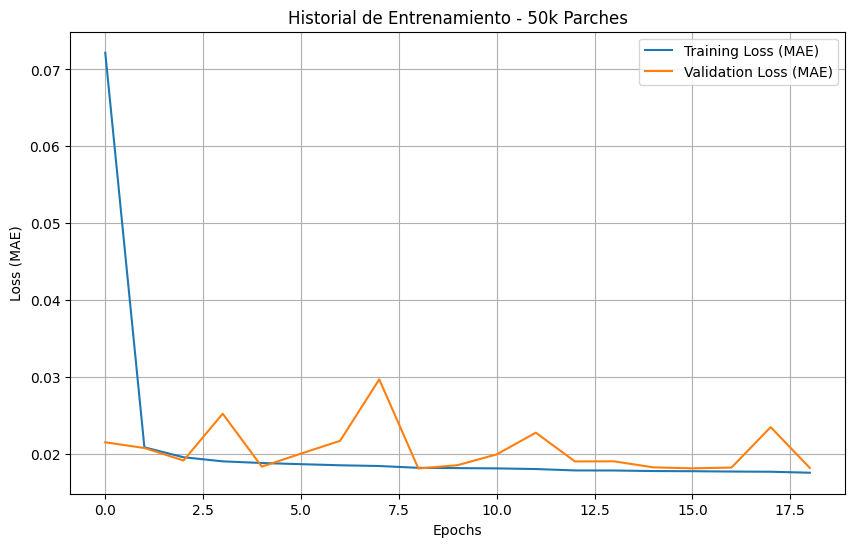

Evaluando el modelo en el conjunto de test...


NameError: name 'generador_test' is not defined

In [ ]:
import matplotlib.pyplot as plt
# ==========================================
# 5. EVALUACIÓN Y GRÁFICAS DE MÉTRICAS
# ==========================================
# Curva de pérdida
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label="Training Loss (MAE)")
plt.plot(history.history['val_loss'], label="Validation Loss (MAE)")
plt.title("Historial de Entrenamiento - 50k Parches")
plt.xlabel("Epochs")
plt.ylabel("Loss (MAE)")
plt.legend()
plt.grid(True)
plt.show()

# Extracción de ground truth y predicciones del generador de Test de forma controlada
print("Evaluando el modelo en el conjunto de test...")
y_true_list = []
y_pred_list = []

for i in range(len(generador_test)):
    bx, by = generador_test[i]
    preds = model.predict(bx, verbose=0)
    y_true_list.append(by)
    y_pred_list.append(preds)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

# Al ser porcentajes, obtenemos la clase predominante de cada parche para las métricas estándar
y_true_classes = np.argmax(y_true, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Matriz de Confusión
clases_nombres = [f"Clase {i}" for i in range(19)]
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12,10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=clases_nombres, yticklabels=clases_nombres)
plt.xlabel('Predicciones')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - Clase Predominante')
plt.show()

# Cálculo final de métricas de rendimiento globales
print("\n=== MÉTRICAS FINALES EN TEST ===")
print(f"Accuracy:  {accuracy_score(y_true_classes, y_pred_classes):.4f}")
print(f"Precision: {precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0):.4f}")